# Introduction to Machine Learning — Part 3: Exercises and Challenges

Eight hands-on exercises building on the heart-disease walkthrough. Each exercise has:

- A clear question or task.
- An empty code cell for your attempt.
- A worked solution at the end of this notebook (in the **Solutions** section).

**Try each exercise yourself before peeking at the solutions.** Struggle is the point — that is how the concepts move from "I read it" to "I can do it".

Difficulty: 1, 2, 3 are warm-ups. 4, 5, 6 are core. 7, 8 are stretch goals.


## Setup — run this first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

df = pd.read_csv("heart.csv")
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Setup complete. Train:", X_train.shape, "Test:", X_test.shape)


Setup complete. Train: (242, 13) Test: (61, 13)


## Exercise 1 — EDA warm-up

Using `df`, answer:

1. What percentage of patients in the dataset have heart disease?
2. What is the average `age` for patients with heart disease vs without?
3. Plot the distribution of `chol` (cholesterol) split by `target`. Do you see a difference?


In [2]:
# Your code here


## Exercise 2 — Train a different classifier

Train a `KNeighborsClassifier` (with `n_neighbors=5`) on the **scaled** training data. Report its test accuracy. Compare it to the Logistic Regression baseline (≈ 0.85 on this split).

KNN is distance-based, so scaling matters more here than for tree models.


In [3]:
# Your code here


## Exercise 3 — Hyperparameter exploration

For a Random Forest, try `n_estimators` in `[10, 50, 100, 200, 400]` (keeping `max_depth=6` and `random_state=42`). Plot test accuracy against `n_estimators`.

What do you observe? Does more trees always mean better performance?


In [4]:
# Your code here


## Exercise 4 — Threshold tuning for clinical screening

A clinic deploying this model wants **recall ≥ 0.95** for the disease class — they accept follow-up tests for false alarms but cannot tolerate missed diagnoses.

Using a Logistic Regression model and the test set, find the lowest threshold that achieves recall ≥ 0.95 on the disease class. Report:

- The chosen threshold.
- The precision at that threshold.
- How many false positives that implies (out of how many actual negatives).

Hint: `precision_recall_curve` returns the arrays you need.


In [5]:
# Your code here


## Exercise 5 — Feature engineering

Create a new feature `age_group` by binning `age` into three categories: `young` (< 45), `middle` (45–60), `senior` (> 60). One-hot encode it.

Train a Logistic Regression on the augmented feature set and compare test accuracy to the baseline (no `age_group` feature). Did engineering the feature help?

Reflect: why might binning a continuous variable sometimes help and sometimes hurt?


In [6]:
# Your code here


## Exercise 6 — Cross-validation

Our test set is only 60 patients, so a single train/test split is noisy. Use **5-fold cross-validation** (`cross_val_score`, `cv=5`) on the **full scaled dataset** to estimate Logistic Regression accuracy more robustly.

Report:

- Mean accuracy across the 5 folds.
- Standard deviation across the 5 folds.

How does this compare to the single-split test accuracy?


In [7]:
# Your code here


## Exercise 7 (stretch) — Fairness audit by age group

Using the binned `age_group` feature from Exercise 5, compute precision, recall, and accuracy *separately for each age group* on the test set, using the Logistic Regression model.

Is performance even across groups? If not, where does the model struggle most, and what would you investigate next?


In [8]:
# Your code here


## Exercise 8 (stretch) — Build a Pipeline

Use `sklearn.pipeline.Pipeline` to chain `StandardScaler` and `LogisticRegression` into a single object. Fit it on the **unscaled** `X_train` and evaluate on the **unscaled** `X_test`.

Why is using a Pipeline preferable to manually scaling, especially when you later move to cross-validation or grid search?


In [9]:
# Your code here


---

# Solutions

Try the exercises before reading these. Each solution is one possible answer; there are usually several valid ones.


### Solution 1

Disease rate: 54.5%
target
0    56.601449
1    52.496970
Name: age, dtype: float64


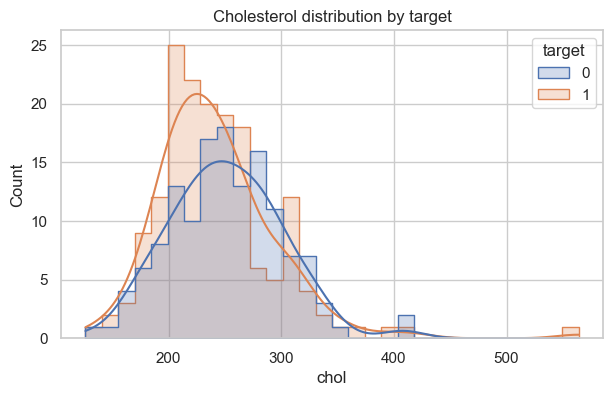

In [10]:
# 1. Percentage with heart disease
print(f"Disease rate: {df['target'].mean():.1%}")

# 2. Mean age by target
print(df.groupby("target")["age"].mean())

# 3. Cholesterol distribution by target
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="chol", hue="target", kde=True, bins=30, element="step")
plt.title("Cholesterol distribution by target")
plt.show()
# Observation: the distributions overlap heavily; chol alone is a weak predictor.


### Solution 2

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print(f"KNN accuracy: {accuracy_score(y_test, knn.predict(X_test_scaled)):.3f}")

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
print(f"LogReg accuracy: {accuracy_score(y_test, logreg.predict(X_test_scaled)):.3f}")


KNN accuracy: 0.803
LogReg accuracy: 0.803


### Solution 3

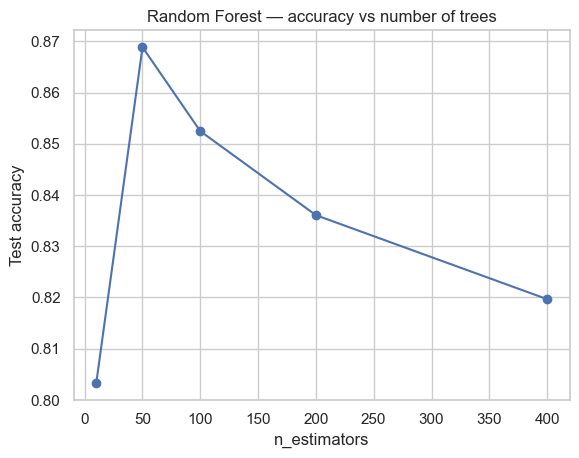

In [12]:
ns = [10, 50, 100, 200, 400]
accs = []
for n in ns:
    rf = RandomForestClassifier(n_estimators=n, max_depth=6, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, rf.predict(X_test)))

plt.plot(ns, accs, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Test accuracy")
plt.title("Random Forest — accuracy vs number of trees")
plt.show()
# Observation: gains plateau quickly. More trees = more compute, diminishing returns.


### Solution 4

In [13]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

# precision_recall_curve returns precision/recall arrays plus the thresholds
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
# precision_recall_curve drops the last threshold; align lengths
mask = rec[:-1] >= 0.95
if mask.any():
    # Pick the threshold giving the highest precision among those meeting recall >= 0.95
    best_idx = np.argmax(prec[:-1][mask])
    chosen_threshold = thresholds[mask][best_idx]
    chosen_precision = prec[:-1][mask][best_idx]
    chosen_recall = rec[:-1][mask][best_idx]
    pred_t = (y_proba >= chosen_threshold).astype(int)
    cm = confusion_matrix(y_test, pred_t)
    tn, fp, fn, tp = cm.ravel()
    print(f"Chosen threshold: {chosen_threshold:.3f}")
    print(f"Precision: {chosen_precision:.3f}")
    print(f"Recall:    {chosen_recall:.3f}")
    print(f"False positives: {fp} out of {fp + tn} actual negatives")
else:
    print("No threshold achieves recall >= 0.95 on this split.")


Chosen threshold: 0.256
Precision: 0.762
Recall:    0.970
False positives: 10 out of 28 actual negatives


### Solution 5

In [14]:
def add_age_group(frame):
    out = frame.copy()
    out["age_group"] = pd.cut(out["age"], bins=[0, 45, 60, 200], labels=["young", "middle", "senior"])
    return pd.get_dummies(out, columns=["age_group"], drop_first=False)

X_train_aug = add_age_group(X_train)
X_test_aug = add_age_group(X_test)

scaler_aug = StandardScaler()
X_train_aug_s = scaler_aug.fit_transform(X_train_aug)
X_test_aug_s = scaler_aug.transform(X_test_aug)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_aug_s, y_train)
print(f"With age_group: {accuracy_score(y_test, logreg.predict(X_test_aug_s)):.3f}")

# Baseline
scaler_b = StandardScaler()
logreg_b = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg_b.fit(scaler_b.fit_transform(X_train), y_train)
print(f"Baseline:       {accuracy_score(y_test, logreg_b.predict(scaler_b.transform(X_test))):.3f}")
# Binning throws away ordering information. Helps when the relationship is non-monotonic;
# hurts when the model could already exploit the continuous feature.


With age_group: 0.803
Baseline:       0.803


### Solution 6

In [15]:
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
scores = cross_val_score(logreg, X_scaled_full, y, cv=5, scoring="accuracy")

print(f"Fold accuracies: {scores.round(3)}")
print(f"Mean: {scores.mean():.3f}  Std: {scores.std():.3f}")
# Note: scaling on the full dataset before CV leaks a small amount of information
# across folds. The cleaner approach is the Pipeline in Exercise 8.


Fold accuracies: [0.82  0.885 0.836 0.867 0.767]
Mean: 0.835  Std: 0.041


### Solution 7

In [16]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)

audit = X_test.copy()
audit["actual"] = y_test.values
audit["pred"] = y_pred
audit["age_group"] = pd.cut(audit["age"], bins=[0, 45, 60, 200], labels=["young", "middle", "senior"])

def metrics(group):
    cm = confusion_matrix(group["actual"], group["pred"], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    n = len(group)
    return pd.Series({
        "n": n,
        "accuracy": (tp + tn) / n if n else 0.0,
        "precision": tp / (tp + fp) if (tp + fp) else 0.0,
        "recall": tp / (tp + fn) if (tp + fn) else 0.0,
    })

print(audit.groupby("age_group").apply(metrics))
# Look at the recall column. A gap between groups, especially with small n, signals
# you should collect more data for the weaker group rather than ship the model.


              n  accuracy  precision    recall
age_group                                     
young      10.0  1.000000   1.000000  1.000000
middle     36.0  0.777778   0.720000  0.947368
senior     15.0  0.733333   0.666667  0.666667


### Solution 8

In [17]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pipe.fit(X_train, y_train)
print(f"Pipeline accuracy: {accuracy_score(y_test, pipe.predict(X_test)):.3f}")

# Pipelines guarantee the scaler is fit only on the training data inside each
# CV fold, preventing data leakage. They also turn the entire workflow into a
# single object you can pass to GridSearchCV or save with joblib.
scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
print(f"CV mean: {scores.mean():.3f}  Std: {scores.std():.3f}")


Pipeline accuracy: 0.803
CV mean: 0.835  Std: 0.041


## Where next

- Try the same workflow on the `titanic.ipynb` dataset bundled in this folder — different domain, same techniques.
- Browse Zindi (https://zindi.africa) for live, Africa-relevant ML competitions with real datasets.
- For a deeper treatment of evaluation and fairness, read Chapter 4 of *Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow* (Géron) and the *Fairness and Machine Learning* online textbook (Barocas, Hardt, Narayanan).
